# AI3003 HW2：CNN 识别 Fashion-MNIST

## 数据加载

In [7]:
# 设置随机种子，使实验结果可重复
import random
import torch
import numpy as np

seed = 42

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

random.seed(seed)
torch.manual_seed(seed)
if device.type == "cuda":
    torch.cuda.manual_seed_all(seed)
torch.use_deterministic_algorithms(True)
np.random.seed(seed)

print(f"Using device: {device}")

Using device: cuda


In [15]:
# 下载 Fashion-MNIST 数据集
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

transform = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Normalize((0.2860,), (0.3530,)),  # Fashion-MNIST的均值和标准差
    ]
)

# 加载完整数据集（全量）
full_train = datasets.FashionMNIST(
    root="./data", train=True, download=True, transform=transform
)
full_test = datasets.FashionMNIST(root="./data", train=False, download=True, transform=transform)

# 将训练集划分为训练集和验证集
from torch.utils.data import random_split
train_size = int((5/6) * len(full_train))
val_size = len(full_train) - train_size
train_set, val_set = random_split(full_train, [train_size, val_size])

# 创建 DataLoader。batch 直接来自 GPU 上的 TensorDataset
BATCH_SIZE = 1024
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_set,   batch_size=BATCH_SIZE)
test_loader  = DataLoader(full_test, batch_size=BATCH_SIZE)

# 打印三个数据集的大小和设备
print(f"Train set size: {len(train_loader.dataset)}")
print(f"Validation set size: {len(val_loader.dataset)}")
print(f"Test set size: {len(test_loader.dataset)}")

Train set size: 50000
Validation set size: 10000
Test set size: 10000


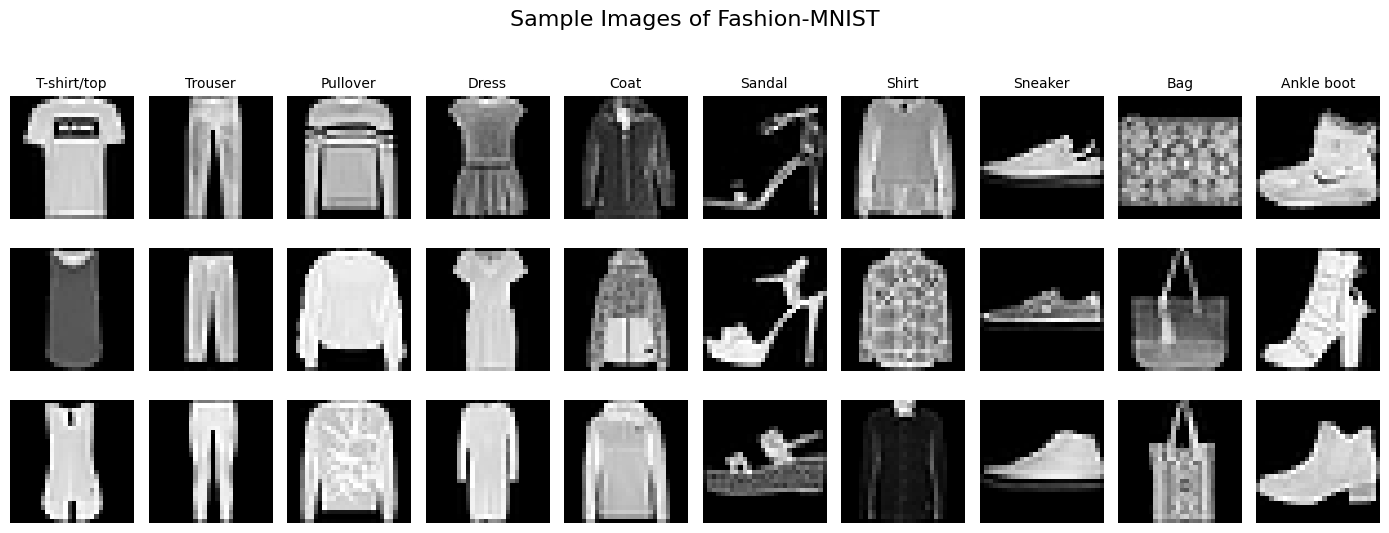

In [16]:
import matplotlib.pyplot as plt
import torch

# 反归一化，便于可视化
mean = torch.tensor(0.2860)
std = torch.tensor(0.3530)

class_names = full_train.classes
samples_per_class = 3
num_classes = len(class_names)

# 为每个类别收集 3 张示例图
class_samples = {i: [] for i in range(num_classes)}
for image, label in full_train:
    if len(class_samples[label]) < samples_per_class:
        class_samples[label].append(image)
    if all(len(v) == samples_per_class for v in class_samples.values()):
        break


fig, axes = plt.subplots(samples_per_class, num_classes, figsize=(num_classes * 1.4, samples_per_class * 1.8))
fig.suptitle("Sample Images of Fashion-MNIST", fontsize=16, y=1.02)

for row in range(samples_per_class):
    for col in range(num_classes):
        ax = axes[row, col]
        img = class_samples[col][row] * std + mean
        ax.imshow(img.squeeze(), cmap="gray")
        ax.axis("off")
        if row == 0:
            ax.set_title(class_names[col], fontsize=10)

plt.tight_layout()
plt.show()


## 对比实验

In [24]:
from cnn import CNN, train_model

model_baseline = CNN(
    hidden_layers = 6,
    hidden_channels = [8, 8, 16, 16, 32, 32],
    apply_pooling = [False, True, False, True, False, True],
    use_batch_norm = True,
).to(device=device)
optimizer_baseline = torch.optim.Adam(model_baseline.parameters(), lr=0.001)
history_baseline = train_model(
    model=model_baseline,
    optimizer=optimizer_baseline,
    train_loader=train_loader,
    val_loader=val_loader,
    num_epochs=50,
    device=device,
)

Epoch:   0%|          | 0/50 [00:00<?, ?it/s]

Batch 1/50:   0%|          | 0/49 [00:00<?, ?it/s]

Batch 2/50:   0%|          | 0/49 [00:00<?, ?it/s]

Batch 3/50:   0%|          | 0/49 [00:00<?, ?it/s]

Batch 4/50:   0%|          | 0/49 [00:00<?, ?it/s]

...

Batch 46/50:   0%|          | 0/49 [00:00<?, ?it/s]

Batch 47/50:   0%|          | 0/49 [00:00<?, ?it/s]

Batch 48/50:   0%|          | 0/49 [00:00<?, ?it/s]

Batch 49/50:   0%|          | 0/49 [00:00<?, ?it/s]

Batch 50/50:   0%|          | 0/49 [00:00<?, ?it/s]

In [25]:
num_params_baseline = sum(p.numel() for p in model_baseline.parameters())
print(f"Number of parameters in the baseline model: {num_params_baseline}")

Number of parameters in the baseline model: 21154


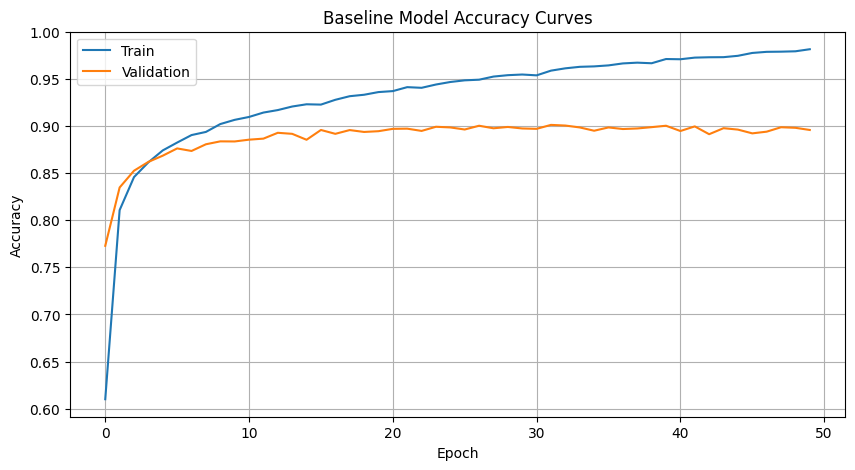

In [26]:
# plot the training and validation loss curves
plt.figure(figsize=(10, 5))
plt.plot(history_baseline["train_accuracies"], label="Train")
plt.plot(history_baseline["val_accuracies"], label="Validation")
plt.title("Baseline Model Accuracy Curves")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()
plt.show()

In [ ]:
from cnn import CNN, train_model

model_large = CNN(
    hidden_layers = 6,
    hidden_channels = [32, 32, 64, 64, 128, 128],
    apply_pooling = [False, True, False, True, False, True],
    use_batch_norm = True,
).to(device=device)
optimizer_large = torch.optim.Adam(model_large.parameters(), lr=0.001)
history_large = train_model(
    model=model_large,
    optimizer=optimizer_large,
    train_loader=train_loader,
    val_loader=val_loader,
    num_epochs=50,
    device=device,
)

Epoch:   0%|          | 0/50 [00:00<?, ?it/s]

Batch 1/50:   0%|          | 0/49 [00:00<?, ?it/s]

Batch 2/50:   0%|          | 0/49 [00:00<?, ?it/s]

Batch 3/50:   0%|          | 0/49 [00:00<?, ?it/s]

Batch 4/50:   0%|          | 0/49 [00:00<?, ?it/s]

...

Batch 46/50:   0%|          | 0/49 [00:00<?, ?it/s]

Batch 47/50:   0%|          | 0/49 [00:00<?, ?it/s]

Batch 48/50:   0%|          | 0/49 [00:00<?, ?it/s]

Batch 49/50:   0%|          | 0/49 [00:00<?, ?it/s]

Batch 50/50:   0%|          | 0/49 [00:00<?, ?it/s]

In [19]:
# parameter count for the large model
num_params_large = sum(p.numel() for p in model_large.parameters())
print(f"Number of parameters in the large model: {num_params_large}")

Number of parameters in the large model: 298858


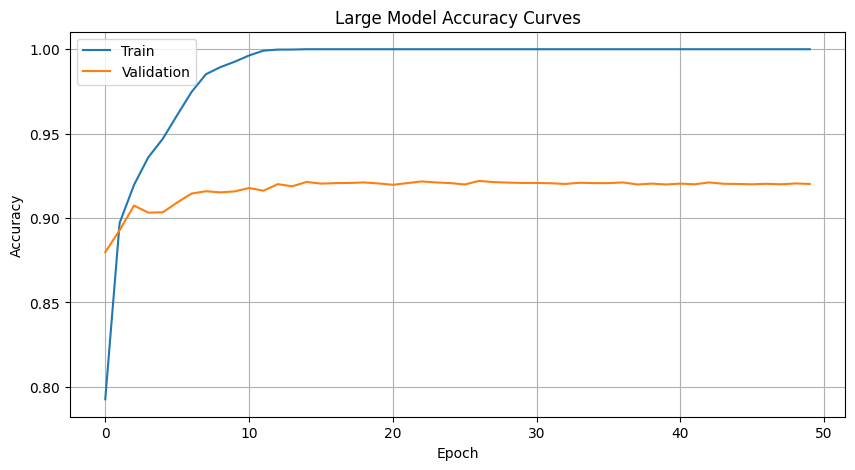

In [23]:
# plot the training and validation loss curves
plt.figure(figsize=(10, 5))
plt.plot(history_large["train_accuracies"], label="Train")
plt.plot(history_large["val_accuracies"], label="Validation")
plt.title("Large Model Accuracy Curves")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()
plt.show()

In [ ]:
model_large = CNN(
    
)